In [102]:
#!pip install xgboost

In [103]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier 
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [104]:
# Carregando dados 
url = "https://raw.githubusercontent.com/vbomura/tc5/main/Codigos/base_anos_limpo.xlsx"
dfBaseAnosLimpos = pd.read_excel(url)

In [105]:
dfBaseAnosLimpos['fase'].unique()

array(['FASE 7', 'FASE 6', 'FASE 5', 'FASE 4', 'FASE 3', 'FASE 2',
       'FASE 1', 'ALFA'], dtype=object)

In [106]:
map_fase = {
    'ALFA': 0,
    'FASE 1': 1,
    'FASE 2': 2,
    'FASE 3': 3,
    'FASE 4': 4,
    'FASE 5': 5,
    'FASE 6': 6,
    'FASE 7': 7,
    'FASE 8': 8
}

In [107]:
dfBaseAnosLimpos['fase_num'] = dfBaseAnosLimpos['fase'].map(map_fase)
dfBaseAnosLimpos['fase_ideal_num'] = dfBaseAnosLimpos['fase_ideal'].map(map_fase)

In [108]:
# Definição das colunas de entrada (features) e do alvo (target)
#features = ['ian', 'ida', 'ieg', 'iaa', 'ips', 'ipp', 'ipv']
#features = ['idade','ian', 'ida', 'ieg', 'ipp', 'ipv']
features = ['idade','fase_num','ian', 'ipv']
target = 'defasagem'

In [109]:
dfBaseAnosLimpos

,ra,fase_original,turma,nome_anonimizado,ano_nasc_original,idade_original,genero,ano_ingresso,instituicao_de_ensino,pedra,...,fase_ideal_original,defasagem,ano_aba,ano_nascimento,fase,fase_ideal,ipp,idade,fase_num,fase_ideal_num
0,RA-1,7,A,Aluno-1,2003,19,Feminino,2016,Escola Pública,Quartzo,...,Fase 8 (Universitários),-1,2022,2003,FASE 7,FASE 8,NaN,19,7,8
1,RA-2,7,A,Aluno-2,2005,17,Feminino,2017,Rede Decisão,Ametista,...,Fase 7 (3º EM),0,2022,2005,FASE 7,FASE 7,NaN,17,7,7
2,RA-3,7,A,Aluno-3,2005,17,Feminino,2016,Rede Decisão,Ágata,...,Fase 7 (3º EM),0,2022,2005,FASE 7,FASE 7,NaN,17,7,7
3,RA-4,7,A,Aluno-4,2005,17,Masculino,2017,Rede Decisão,Quartzo,...,Fase 7 (3º EM),0,2022,2005,FASE 7,FASE 7,NaN,17,7,7
4,RA-5,7,A,Aluno-5,2005,17,Feminino,2016,Rede Decisão,Ametista,...,Fase 7 (3º EM),0,2022,2005,FASE 7,FASE 7,NaN,17,7,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2840,RA-291,7E,7E,Aluno-291,2009-01-17 00:00:00,15,Masculino,2022,Privada - Programa de Apadrinhamento,Ametista,...,Fase 5 (1° EM),2,2024,2009,FASE 7,FASE 5,7.5,15,7,5
2841,RA-86,7E,7E,Aluno-86,2006-10-04 00:00:00,18,Masculino,2021,Privada *Parcerias com Bolsa 100%,Ametista,...,Fase 7 (3° EM),0,2024,2006,FASE 7,FASE 7,7.5,18,7,7
2842,RA-143,7E,7E,Aluno-143,2009-08-01 00:00:00,15,Masculino,2021,Privada - Programa de Apadrinhamento,Ametista,...,Fase 5 (1° EM),2,2024,2009,FASE 7,FASE 5,7.5,15,7,5
2843,RA-166,7E,7E,Aluno-166,2008-06-03 00:00:00,16,Masculino,2021,Privada *Parcerias com Bolsa 100%,Topázio,...,Fase 6 (2° EM),1,2024,2008,FASE 7,FASE 6,7.5,16,7,6


In [110]:
# Calculate the median of each numeric column
medians_by_column = dfBaseAnosLimpos[features].median()

print("\nMedians by Column:")
print(medians_by_column)


Medians by Column:
idade       12.000
fase_num     2.000
ian          5.000
ipv          7.583
dtype: float64


In [111]:
print(dfBaseAnosLimpos[features].describe())

             idade     fase_num          ian          ipv
count  2845.000000  2845.000000  2845.000000  2845.000000
mean     12.164851     2.205272     7.010545     7.545910
std       2.761989     1.822477     2.510504     1.085439
min       7.000000     0.000000     2.500000     2.500000
25%      10.000000     1.000000     5.000000     6.966000
50%      12.000000     2.000000     5.000000     7.583000
75%      14.000000     3.000000    10.000000     8.255000
max      22.000000     7.000000    10.000000    10.010000


In [112]:
# Verificando se existem valores nulos e removendo-os
df_model = dfBaseAnosLimpos[features + [target]].dropna()

df_model

,idade,fase_num,ian,ipv,defasagem
0,19,7,5.0,7.278,-1
1,17,7,10.0,6.778,0
2,17,7,10.0,7.556,0
3,17,7,10.0,5.278,0
4,17,7,10.0,7.389,0
...,...,...,...,...,...
2840,15,7,10.0,7.500,2
2841,18,7,10.0,7.500,0
2842,15,7,10.0,7.500,2
2843,16,7,10.0,7.500,1


In [113]:
X = df_model[features]
y = df_model[target]

# Separando em treino/teste 20%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [114]:
# Instanciando o modelo
# max_iter=1000 garante que o modelo tenha tentativas suficientes para convergir em dados complexos
log_model = LogisticRegression(max_iter=1000, random_state=42)

# Treinando
log_model.fit(X_train, y_train)

# Prevendo
y_pred_log = log_model.predict(X_test)

# Avaliando
print("--- Regressão Logística ---")
print(f"Acurácia: {accuracy_score(y_test, y_pred_log):.2%}\n")
print(classification_report(y_test, y_pred_log))

--- Regressão Logística ---
Acurácia: 88.75%

              precision    recall  f1-score   support

          -4       0.00      0.00      0.00         1
          -3       0.89      1.00      0.94         8
          -2       0.84      0.65      0.73        80
          -1       0.89      0.96      0.92       243
           0       0.91      1.00      0.95       205
           1       0.71      0.19      0.29        27
           2       0.50      0.50      0.50         4
           3       0.00      0.00      0.00         1

    accuracy                           0.89       569
   macro avg       0.59      0.54      0.54       569
weighted avg       0.88      0.89      0.87       569



In [115]:
# 1. Preparação dos dados com LabelEncoder (A CORREÇÃO ESTÁ AQUI)
le = LabelEncoder()
y_encoded = le.fit_transform(y) # Transforma [-4, -3...] em [0, 1...]

# Refazendo o split com o y_encoded
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)

# 2. Instanciando o modelo
# Removemos use_label_encoder=False pois já codificamos manualmente acima
# 'mlogloss' é melhor para multiclasse (várias categorias de defasagem)
xgb_model = XGBClassifier(eval_metric='mlogloss', random_state=42)

# 3. Treinando
xgb_model.fit(X_train, y_train)

# 4. Prevendo
y_pred_xgb = xgb_model.predict(X_test)

# 5. Avaliando (Traduzindo de volta para os números originais para o print fazer sentido)
y_test_original = le.inverse_transform(y_test)
y_pred_original = le.inverse_transform(y_pred_xgb)

print("--- XGBoost ---")
print(f"Acurácia: {accuracy_score(y_test_original, y_pred_original):.2%}\n")
print(classification_report(y_test_original, y_pred_original))

--- XGBoost ---
Acurácia: 90.40%

              precision    recall  f1-score   support

          -4       0.00      0.00      0.00         1
          -3       0.92      0.92      0.92        13
          -2       0.77      0.80      0.78       123
          -1       0.93      0.92      0.93       365
           0       0.95      0.98      0.96       308
           1       0.73      0.51      0.60        37
           2       0.67      0.67      0.67         6
           3       0.00      0.00      0.00         1

    accuracy                           0.90       854
   macro avg       0.62      0.60      0.61       854
weighted avg       0.90      0.90      0.90       854



In [116]:



model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\n--- Relatório de Classificação ---")
print(classification_report(y_test, y_pred))

print("\n--- Acurácia ---")
print(f"{accuracy_score(y_test, y_pred):.2%}")


--- Relatório de Classificação ---
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         1
           2       0.93      1.00      0.96        13
           3       0.77      0.81      0.79       123
           4       0.94      0.92      0.93       365
           5       0.96      0.98      0.97       308
           6       0.73      0.59      0.66        37
           7       0.67      0.67      0.67         6
           8       0.00      0.00      0.00         1

    accuracy                           0.91       854
   macro avg       0.62      0.62      0.62       854
weighted avg       0.91      0.91      0.91       854


--- Acurácia ---
90.87%


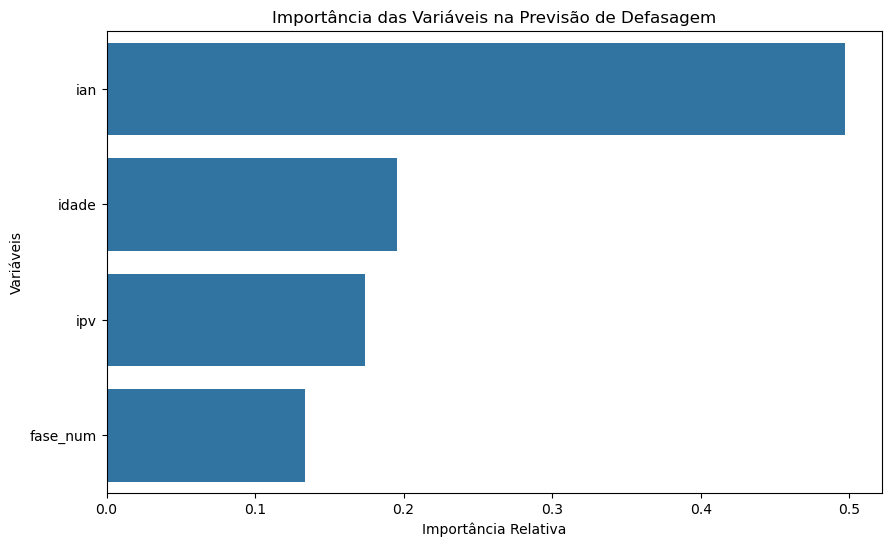

In [117]:
#Visualização da Importância das Variáveis no RandomForestClassifier
feature_importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances, y=feature_importances.index)
plt.title('Importância das Variáveis na Previsão de Defasagem')
plt.xlabel('Importância Relativa')
plt.ylabel('Variáveis')
plt.show()

# Criação de arquivo Modelo para usar no Streamlit

In [118]:
#import joblib
#Criando joblib da predição
#joblib.dump(model,'RandomForest.joblib')